# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [34]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [35]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [36]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [37]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [38]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [39]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

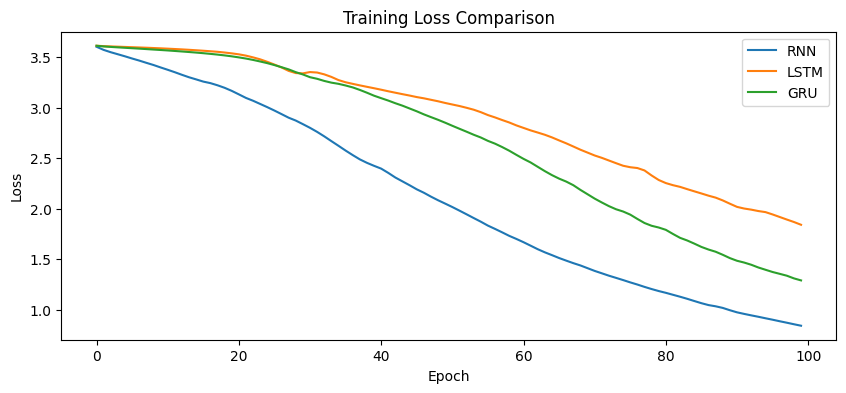

In [40]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [41]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [42]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is transforming artificial intelligence than
LSTM: deep learning learning models artificial meaningful sentences
GRU : deep learning models models the next word


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# NEW CORPUS


In [94]:
corpus = '''
From fairest creatures we desire increase,
That thereby beauty's rose might never die,
But as the riper should by time decease,
His tender heir might bear his memory:
But thou contracted to thine own bright eyes,
Feed'st thy light's flame with self-substantial fuel,
Making a famine where abundance lies,
Thy self thy foe, to thy sweet self too cruel:
Thou that art now the world's fresh ornament,
And only herald to the gaudy spring,
Within thine own bud buriest thy content,
And tender churl mak'st waste in niggarding:
Pity the world, or else this glutton be,
To eat the world's due, by the grave and thee.
'''
print(corpus)


From fairest creatures we desire increase,
That thereby beauty's rose might never die,
But as the riper should by time decease,
His tender heir might bear his memory:
But thou contracted to thine own bright eyes,
Feed'st thy light's flame with self-substantial fuel,
Making a famine where abundance lies,
Thy self thy foe, to thy sweet self too cruel:
Thou that art now the world's fresh ornament,
And only herald to the gaudy spring,
Within thine own bud buriest thy content,
And tender churl mak'st waste in niggarding:
Pity the world, or else this glutton be,
To eat the world's due, by the grave and thee.



In [95]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 82
X shape: (93, 9)
y shape: (93,)


# Increased Embeddings

In [96]:
# Increased Vanilla RNN embedding dimension to 64
rnn_model_emb64 = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model_emb64.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model_emb64.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training with embedding dimension 64 completed")

Vanilla RNN training with embedding dimension 64 completed


In [97]:
# Increased lstm embedding dimension to 64
lstm_model_emb64 = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model_emb64.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_model_emb64.fit(X, y, epochs=100, verbose=0)
print("LSTM with embedding dimension 64 training completed")

LSTM with embedding dimension 64 training completed


In [98]:
# Increased GRU embedding dimension to 64
gru_model_emb64 = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model_emb64.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model_emb64.fit(X, y, epochs=100, verbose=0)
print("GRU training with embedding dimension 64 completed")

GRU training with embedding dimension 64 completed


# Increased Epochs to 200

In [99]:
# Increase Vanilla epochs to 200
rnn_model_200 = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model_200.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history_200 = rnn_model_200.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed for 200 epochs")

Vanilla RNN training completed for 200 epochs


In [100]:
# Increase LSTM epochs to 200
lstm_model_200 = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model_200.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history_200 = lstm_model_200.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed for 200 epochs")

LSTM training completed for 200 epochs


In [101]:
# Increase GRU epochs to 200

gru_model_200 = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model_200.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history_200 = gru_model_200.fit(X, y, epochs=200, verbose=0)
print("GRU training completed for 200 epochs")

GRU training completed for 200 epochs


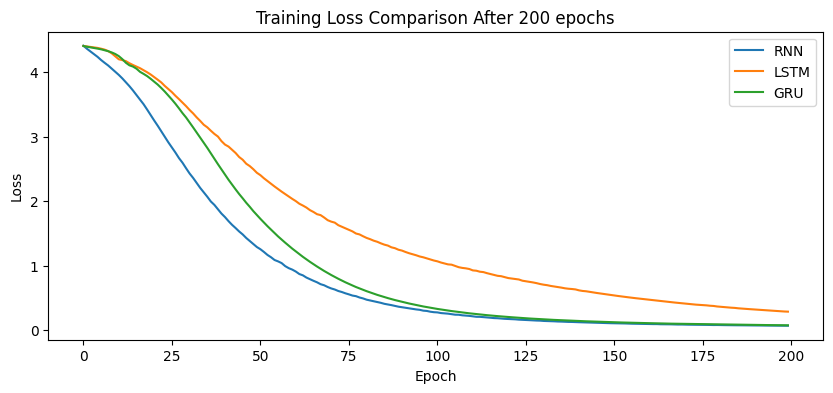

In [102]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history_200.history['loss'], label='RNN')
plt.plot(lstm_history_200.history['loss'], label='LSTM')
plt.plot(gru_history_200.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison After 200 epochs")
plt.legend()
plt.show()

# Changing hidden units 64 → 128

In [103]:
# Change Vanilla RNN hidden units 64 -> 128
rnn_model_128 = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model_128.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

rnn_model_128.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN with 128 hidden units training completed")

Vanilla RNN with 128 hidden units training completed


In [104]:
# Change LSTM hidden units 64 -> 128
lstm_model_128 = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model_128.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_model_128.fit(X, y, epochs=200, verbose=0)
print("LSTM with 128 hidden units training completed")

LSTM with 128 hidden units training completed


In [105]:
# Changed GRU hidden units 64 -> 128
gru_model_128 = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model_128.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

gru_model_128.fit(X, y, epochs=200, verbose=0)
print("GRU with 128 hidden units training completed")

GRU with 128 hidden units training completed


# Generated 10 words instead of 5

## Using Dropout



In [106]:
# Vanilla RNN with Dropout
rnn_model_dropout = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    tf.keras.layers.Dropout(0.2), # Add dropout after the RNN layer
    Dense(total_words, activation='softmax')
])

rnn_model_dropout.compile(loss='sparse_categorical_crossentropy',
                           optimizer='adam',
                           metrics=['accuracy'])

rnn_history_dropout = rnn_model_dropout.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN with Dropout training completed")

Vanilla RNN with Dropout training completed


In [107]:
# LSTM with Dropout
lstm_model_dropout = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    tf.keras.layers.Dropout(0.2), # Add dropout after the LSTM layer
    Dense(total_words, activation='softmax')
])

lstm_model_dropout.compile(loss='sparse_categorical_crossentropy',
                            optimizer='adam',
                            metrics=['accuracy'])

lstm_history_dropout = lstm_model_dropout.fit(X, y, epochs=200, verbose=0)
print("LSTM with Dropout training completed")

LSTM with Dropout training completed


In [108]:
# GRU with Dropout
gru_model_dropout = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    tf.keras.layers.Dropout(0.2), # Add dropout after the GRU layer
    Dense(total_words, activation='softmax')
])

gru_model_dropout.compile(loss='sparse_categorical_crossentropy',
                           optimizer='adam',
                           metrics=['accuracy'])

gru_history_dropout = gru_model_dropout.fit(X, y, epochs=200, verbose=0)
print("GRU with Dropout training completed")

GRU with Dropout training completed


# Early Stopping



In [109]:
# Define EarlyStopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Monitor the validation loss
    patience=10,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Define new models with Dropout and Early Stopping

# Vanilla RNN with Dropout and Early Stopping
rnn_model_dropout_es = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    tf.keras.layers.Dropout(0.2),
    Dense(total_words, activation='softmax')
])

rnn_model_dropout_es.compile(loss='sparse_categorical_crossentropy',
                              optimizer='adam',
                              metrics=['accuracy'])

rnn_history_dropout_es = rnn_model_dropout_es.fit(
    X, y, epochs=200, verbose=0, validation_split=0.2, callbacks=[early_stopping]
)
print("Vanilla RNN with Dropout and Early Stopping training completed")

Vanilla RNN with Dropout and Early Stopping training completed


In [110]:
# LSTM with Dropout and Early Stopping
lstm_model_dropout_es = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    tf.keras.layers.Dropout(0.2),
    Dense(total_words, activation='softmax')
])

lstm_model_dropout_es.compile(loss='sparse_categorical_crossentropy',
                               optimizer='adam',
                               metrics=['accuracy'])

lstm_history_dropout_es = lstm_model_dropout_es.fit(
    X, y, epochs=200, verbose=0, validation_split=0.2, callbacks=[early_stopping]
)
print("LSTM with Dropout and Early Stopping training completed")

LSTM with Dropout and Early Stopping training completed


In [111]:
# GRU with Dropout and Early Stopping
gru_model_dropout_es = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    tf.keras.layers.Dropout(0.2),
    Dense(total_words, activation='softmax')
])

gru_model_dropout_es.compile(loss='sparse_categorical_crossentropy',
                              optimizer='adam',
                              metrics=['accuracy'])

gru_history_dropout_es = gru_model_dropout_es.fit(
    X, y, epochs=200, verbose=0, validation_split=0.2, callbacks=[early_stopping]
)
print("GRU with Dropout and Early Stopping training completed")

GRU with Dropout and Early Stopping training completed


## 📉 Training Loss Comparison with Regularization

Let's compare the training losses of the models:
1.  Original models (200 epochs, 128 hidden units)
2.  Models with Dropout (200 epochs, 128 hidden units, 0.2 dropout rate)
3.  Models with Dropout and Early Stopping (200 epochs, 128 hidden units, 0.2 dropout rate, 0.2 validation split, patience 10)

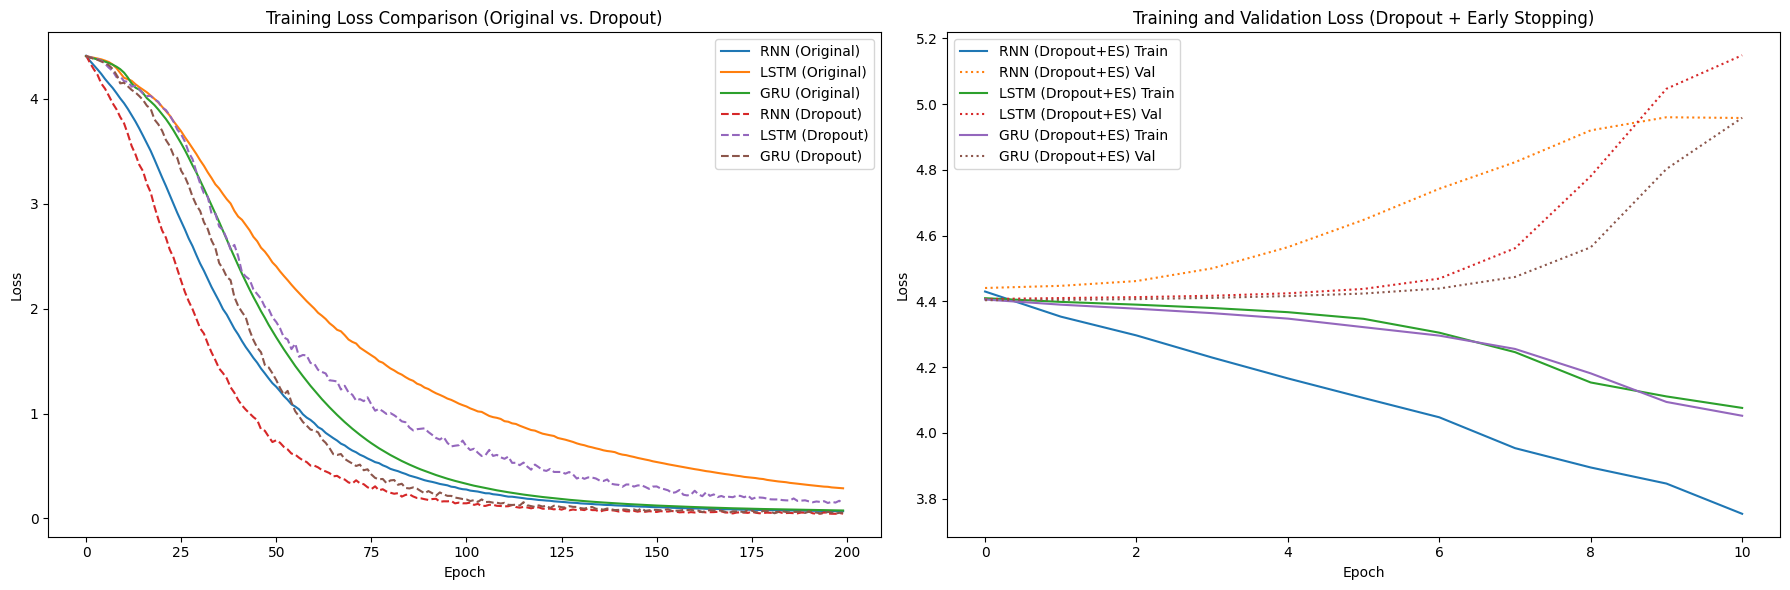

In [112]:
plt.figure(figsize=(18, 6))

# Plot for Original Models vs Dropout Models (Training Loss)
plt.subplot(1, 2, 1)
plt.plot(rnn_history_200.history['loss'], label='RNN (Original)')
plt.plot(lstm_history_200.history['loss'], label='LSTM (Original)')
plt.plot(gru_history_200.history['loss'], label='GRU (Original)')

plt.plot(rnn_history_dropout.history['loss'], label='RNN (Dropout)', linestyle='--')
plt.plot(lstm_history_dropout.history['loss'], label='LSTM (Dropout)', linestyle='--')
plt.plot(gru_history_dropout.history['loss'], label='GRU (Dropout)', linestyle='--')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison (Original vs. Dropout)")
plt.legend()

# Plot for Dropout Models with Early Stopping (Training and Validation Loss)
plt.subplot(1, 2, 2)
plt.plot(rnn_history_dropout_es.history['loss'], label='RNN (Dropout+ES) Train')
plt.plot(rnn_history_dropout_es.history['val_loss'], label='RNN (Dropout+ES) Val', linestyle=':')

plt.plot(lstm_history_dropout_es.history['loss'], label='LSTM (Dropout+ES) Train')
plt.plot(lstm_history_dropout_es.history['val_loss'], label='LSTM (Dropout+ES) Val', linestyle=':')

plt.plot(gru_history_dropout_es.history['loss'], label='GRU (Dropout+ES) Train')
plt.plot(gru_history_dropout_es.history['val_loss'], label='GRU (Dropout+ES) Val', linestyle=':')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss (Dropout + Early Stopping)")
plt.legend()

plt.tight_layout()
plt.show()

## ✍️ Generated Text Samples with Regularized Models

Let's see how the text generation capabilities of the regularized models compare.

In [114]:
print("RNN (Dropout + ES) :", generate_text(rnn_model_dropout_es, "Creature", 10))
print("LSTM (Dropout + ES):", generate_text(lstm_model_dropout_es, "Creature", 10))
print("GRU (Dropout + ES) :", generate_text(gru_model_dropout_es, "Creature", 10))

RNN (Dropout + ES) : Creature we decease decease decease creatures creatures creatures creatures rose else
LSTM (Dropout + ES): Creature bear bear bear bear spring spring tender tender might might
GRU (Dropout + ES) : Creature thine fairest thy sweet self substantial too the the fresh


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**